In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Print shapes
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

# Class names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 85s 3us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 8s 2us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


### Dataset Shapes and Basic Understanding

The Fashion-MNIST dataset has been successfully loaded and inspected.

- The training data `x_train` has a shape of **(60000, 28, 28)**, which means there are 60,000 grayscale images, each of size 28×28 pixels.
- The training labels `y_train` have a shape of **(60000,)**, indicating one label per training image.
- The test data `x_test` has a shape of **(10000, 28, 28)**, meaning there are 10,000 test images.
- The test labels `y_test` have a shape of **(10000,)**.

Each image belongs to one of **10 different classes**, such as T-shirt, Trouser, Sneaker, etc.

This confirms that the dataset is properly structured for a supervised classification task, where:
- Input: image (28×28 pixels)
- Output: class label (0–9)

The data is currently in 2D format (height × width), which will later be reshaped to include a channel dimension for CNN input.

### Why is normalization required for image data?

Normalization is the process of scaling pixel values from their original range (0–255) to a smaller range, typically 0–1.

This is important because:
- Neural networks perform better when input values are small and consistent.
- Large input values can slow down training and make optimization harder.
- It helps the model converge faster during training.
- It reduces the chances of unstable gradients.

In the case of image data, dividing pixel values by 255 ensures all inputs are within the same scale, improving learning efficiency.

---

### Why do CNNs require reshaped image inputs?

Convolutional Neural Networks (CNNs) expect input data in a specific format that includes a channel dimension.

Currently, each image has shape:
(28, 28)

But CNNs require:
(28, 28, 1)

Where:
- 28 = height
- 28 = width
- 1 = number of channels (grayscale image)

This extra dimension is necessary because convolution operations are applied across channels. Even though grayscale images have only one channel, it must still be explicitly provided.

Without reshaping, the CNN model will not be able to process the data correctly.

In [2]:
# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to add channel dimension (28,28 → 28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New x_train shape:", x_train.shape)
print("New x_test shape:", x_test.shape)

New x_train shape: (60000, 28, 28, 1)
New x_test shape: (10000, 28, 28, 1)


### Data Normalization and Reshaping

The image data has been preprocessed before feeding it into the CNN model.

#### Normalization
The pixel values were originally in the range **0 to 255**. These values were scaled down to the range **0 to 1** by dividing by 255.

This helps in:
- Faster convergence during training
- More stable gradient updates
- Improved overall model performance

#### Reshaping
The original shape of each image was **(28, 28)**, which represents height and width.

It was reshaped to **(28, 28, 1)** by adding a channel dimension:
- 28 → height
- 28 → width
- 1 → grayscale channel

The full dataset shapes are now:
- Training data: **(60000, 28, 28, 1)**
- Test data: **(10000, 28, 28, 1)**

This format is required because CNN layers expect input data with a channel dimension.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build shallow CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

c:\Users\amitk\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

### Shallow CNN Architecture Explanation

A shallow Convolutional Neural Network (CNN) has been designed with a simple structure suitable for basic image classification tasks.

#### Layer-wise Breakdown

1. **Convolutional Layer (Conv2D)**
   - 32 filters of size (3×3) are applied.
   - Output shape: (26, 26, 32)
   - This layer detects basic features such as edges, textures, and simple patterns.

2. **Max Pooling Layer (MaxPooling2D)**
   - Pool size: (2×2)
   - Output shape: (13, 13, 32)
   - Reduces spatial dimensions and helps retain important features while lowering computation.

3. **Flatten Layer**
   - Converts the 3D feature maps into a 1D vector.
   - Output shape: (5408)
   - Prepares data for the fully connected layer.

4. **Dense Layer (Hidden Layer)**
   - 128 neurons with ReLU activation.
   - Learns higher-level feature combinations from extracted patterns.

5. **Output Layer**
   - 10 neurons (one for each class)
   - Softmax activation is used to output class probabilities.

#### Total Parameters

- Total trainable parameters: **693,962**

Most parameters are in the dense layer, which connects all extracted features to the final classification output.

#### Key Insight

This shallow CNN is capable of learning **basic visual patterns** but may struggle with more complex representations due to its limited depth.

In [4]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8674 - loss: 0.3776 - val_accuracy: 0.8893 - val_loss: 0.3032
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9052 - loss: 0.2571 - val_accuracy: 0.9058 - val_loss: 0.2595
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9215 - loss: 0.2131 - val_accuracy: 0.9071 - val_loss: 0.2552
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9330 - loss: 0.1827 - val_accuracy: 0.9127 - val_loss: 0.2466
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9426 - loss: 0.1549 - val_accuracy: 0.9157 - val_loss: 0.2486
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9503 - loss: 0.1325 - val_accuracy: 0.9114 - val_loss: 0.2676
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9589 - loss: 0.1118 - val_accuracy: 0.9116 - val_loss: 0.2814
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9656 - loss: 0.0946 - 

### Training Performance of Shallow CNN

The shallow CNN model was trained for 10 epochs on the Fashion-MNIST dataset.

#### Final Performance
- Training Accuracy: **~97.3%**
- Validation Accuracy: **~91.8%**
- Training Loss: **~0.07**
- Validation Loss: **~0.30**

#### Observations

1. **Strong Learning Capability**
   - The training accuracy steadily increased from ~86% to ~97%, indicating that the model successfully learned patterns from the training data.

2. **Validation Performance**
   - Validation accuracy improved initially and stabilized around **91–92%**, which shows decent generalization to unseen data.

3. **Overfitting Behavior**
   - A gap is observed between training accuracy (~97%) and validation accuracy (~91%).
   - Validation loss starts increasing after a few epochs while training loss continues to decrease.

   This indicates **mild overfitting**, where the model is learning training data very well but not improving equally on unseen data.

#### Conclusion

The shallow CNN is effective at capturing basic image features and achieves good performance. However, due to its limited depth, it begins to overfit slightly and may not generalize optimally.

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9185 - loss: 0.3054
Test Accuracy: 0.9185000061988831


### Test Set Evaluation of Shallow CNN

The trained shallow CNN model was evaluated on the test dataset to measure its performance on unseen data.

#### Results
- Test Accuracy: **91.85%**
- Test Loss: **~0.305**

#### Interpretation

The test accuracy is very close to the validation accuracy (~91.8%), which indicates that the model generalizes well to new data.

Although there was slight overfitting observed during training (higher training accuracy compared to validation accuracy), it did not significantly harm the model's performance on the test set.

#### Key Insight

The shallow CNN achieves solid performance on the Fashion-MNIST dataset, correctly classifying most images. However, there is still room for improvement, especially in handling more complex or similar-looking classes.

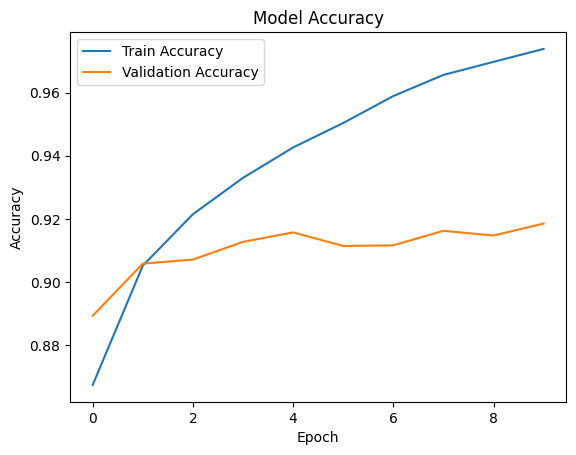

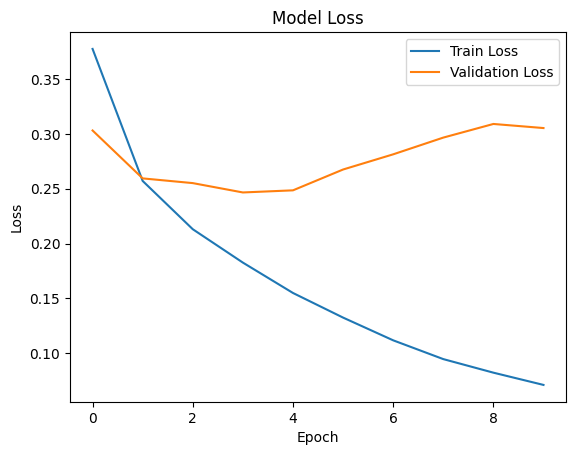

In [28]:
# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.savefig("shallow_accuracy.png")
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.savefig("shallow_loss.png")
plt.show()

### Training and Validation Curves Analysis

The training and validation accuracy and loss were plotted across 10 epochs to understand model behavior.

#### Accuracy Plot Observations

- Training accuracy steadily increases from ~86% to ~97%.
- Validation accuracy improves initially but stabilizes around **91–92%** after a few epochs.
- A noticeable gap appears between training and validation accuracy as epochs increase.

#### Loss Plot Observations

- Training loss continuously decreases, showing that the model is learning well on training data.
- Validation loss decreases initially but starts increasing after around epoch 3–4.
- This divergence indicates that the model is no longer improving on unseen data.

#### Overfitting Analysis

- The increasing gap between training and validation accuracy
- The rise in validation loss while training loss decreases

Both clearly indicate **overfitting**.

#### Key Insight

The shallow CNN learns meaningful patterns early on, but after a few epochs, it begins to memorize the training data instead of generalizing. This suggests that:
- The model capacity is sufficient for basic learning
- But it lacks mechanisms (or depth) to generalize perfectly

Early stopping or regularization could help reduce overfitting in this case.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build deep CNN
deep_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

### Deep CNN Architecture Explanation

A deep Convolutional Neural Network (CNN) was designed with multiple convolutional and pooling layers to capture more complex patterns in the data.

#### Layer-wise Breakdown

1. **First Convolution Block**
   - Conv2D with 32 filters → Output: (26, 26, 32)
   - MaxPooling2D → Output: (13, 13, 32)
   - Learns basic features like edges and simple textures

2. **Second Convolution Block**
   - Conv2D with 64 filters → Output: (11, 11, 64)
   - MaxPooling2D → Output: (5, 5, 64)
   - Learns more detailed patterns and shapes

3. **Third Convolution Layer**
   - Conv2D with 128 filters → Output: (3, 3, 128)
   - Captures higher-level and more abstract features

4. **Flatten Layer**
   - Converts feature maps into a 1D vector of size 1152

5. **Dense Layer**
   - 128 neurons with ReLU activation
   - Learns complex feature combinations

6. **Output Layer**
   - 10 neurons with softmax activation
   - Produces class probabilities

#### Total Parameters

- Total trainable parameters: **241,546**

#### Key Insight

Compared to the shallow CNN:
- This model has **more convolution layers**
- Uses **progressively increasing filters (32 → 64 → 128)**
- Learns **hierarchical representations**, from simple to complex features

Despite being deeper, it uses fewer parameters because the spatial dimensions are reduced before the dense layer.

In [8]:
deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

deep_history = deep_model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8306 - loss: 0.4639 - val_accuracy: 0.8777 - val_loss: 0.3514
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8910 - loss: 0.2964 - val_accuracy: 0.8852 - val_loss: 0.3143
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9059 - loss: 0.2524 - val_accuracy: 0.8954 - val_loss: 0.2800
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9187 - loss: 0.2195 - val_accuracy: 0.9022 - val_loss: 0.2721
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9280 - loss: 0.1926 - val_accuracy: 0.9053 - val_loss: 0.2691
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9352 - loss: 0.1719 - val_accuracy: 0.9060 - val_loss: 0.2790
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9420 - loss: 0.1528 - val_accuracy: 0.9050 - val_loss: 0.2682
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9493 - loss: 0

### Training Performance of Deep CNN

The deep CNN model was trained for 10 epochs on the Fashion-MNIST dataset.

#### Final Performance
- Training Accuracy: **~95.9%**
- Validation Accuracy: **~91.1%**
- Training Loss: **~0.10**
- Validation Loss: **~0.29**

#### Observations

1. **Learning Progress**
   - Training accuracy steadily increased from ~83% to ~95.9%, showing effective learning of features.
   - The model improves more gradually compared to the shallow CNN due to increased complexity.

2. **Validation Performance**
   - Validation accuracy reaches around **91–91.5%**, similar to the shallow CNN.
   - Performance stabilizes after a few epochs.

3. **Overfitting Behavior**
   - There is a gap between training accuracy (~96%) and validation accuracy (~91%).
   - Validation loss fluctuates and slightly increases in later epochs.

   This indicates **moderate overfitting**, though slightly less aggressive than the shallow model.

#### Key Insight

The deep CNN learns more complex and hierarchical features, but this does not lead to a significant improvement in validation accuracy compared to the shallow CNN. The added depth increases learning capacity but does not drastically improve generalization for this dataset.

In [9]:
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test, y_test)

print("Deep CNN Test Accuracy:", deep_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9112 - loss: 0.2927
Deep CNN Test Accuracy: 0.9111999869346619


### Test Set Evaluation of Deep CNN

The deep CNN model was evaluated on the test dataset to assess its performance on unseen data.

#### Results
- Test Accuracy: **91.12%**
- Test Loss: **~0.293**

#### Interpretation

The test accuracy is slightly lower than the shallow CNN (~91.85%), even though the deep model is more complex.

This indicates that:
- The deep CNN is able to generalize reasonably well
- However, the added complexity did not result in better performance on this dataset

#### Key Insight

While deeper networks are capable of learning more complex patterns, they do not always guarantee improved accuracy. In this case, the deep CNN performs similarly, but slightly worse than the shallow CNN on the test set.

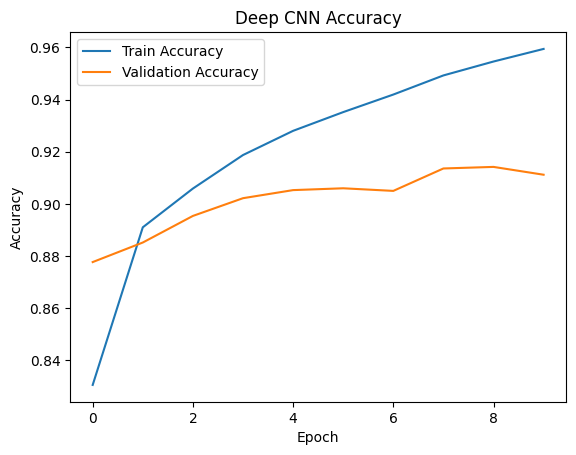

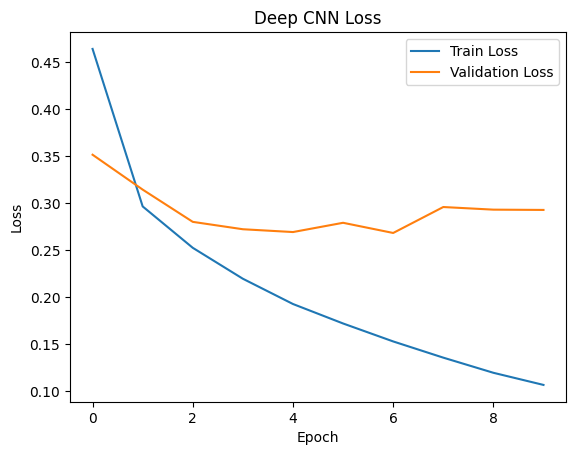

In [30]:
# Plot Accuracy
plt.figure()
plt.plot(deep_history.history['accuracy'])
plt.plot(deep_history.history['val_accuracy'])
plt.title('Deep CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.savefig("deep_accuracy.png")
plt.show()

# Plot Loss
plt.figure()
plt.plot(deep_history.history['loss'])
plt.plot(deep_history.history['val_loss'])
plt.title('Deep CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.savefig("deep_loss.png")
plt.show()

### Training and Validation Curves Analysis (Deep CNN)

The training and validation accuracy and loss were analyzed over 10 epochs for the deep CNN.

#### Accuracy Plot Observations

- Training accuracy steadily increases from ~83% to ~96%.
- Validation accuracy improves initially and stabilizes around **91–91.5%**.
- A gap between training and validation accuracy becomes visible over time.

#### Loss Plot Observations

- Training loss consistently decreases, showing effective learning on training data.
- Validation loss decreases in early epochs but begins to fluctuate and slightly increase after epoch 4–5.

#### Overfitting Analysis

- The divergence between training and validation accuracy
- The increase in validation loss while training loss decreases

These indicate **overfitting**, although it is slightly less pronounced compared to the shallow CNN.

#### Key Insight

The deep CNN is able to learn more complex representations, but this does not translate into significantly better validation performance. The model still struggles to improve generalization despite increased depth.

### What additional patterns or representations might a deep CNN learn?

A deep CNN learns **hierarchical and complex features** across multiple layers:

- Early layers detect basic features such as edges and textures
- Middle layers capture shapes and object parts
- Deeper layers learn high-level representations such as combinations of shapes and class-specific patterns

This allows the model to understand more abstract and detailed structures in images compared to a shallow CNN.

---

### Did the deeper model improve performance meaningfully?

No, the deeper model did **not improve performance significantly**.

- Shallow CNN Test Accuracy: ~91.85%
- Deep CNN Test Accuracy: ~91.12%

Despite having more layers and the ability to learn complex features, the deep CNN achieved slightly lower accuracy.

This suggests that:
- The Fashion-MNIST dataset may not require very deep architectures
- The added complexity did not provide a meaningful advantage
- Simpler models can sometimes perform equally well or better on relatively simple datasets

In [13]:
import time

start_time = time.time()

deep_model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=0
)

end_time = time.time()

deep_training_time = end_time - start_time
print("Deep CNN Training Time:", deep_training_time, "seconds")

Deep CNN Training Time: 120.34243178367615 seconds


In [14]:
import time

start_time = time.time()

model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=0
)

end_time = time.time()

shallow_training_time = end_time - start_time
print("Shallow CNN Training Time:", shallow_training_time, "seconds")

Shallow CNN Training Time: 217.7682602405548 seconds


### Comparative Study: Shallow CNN vs Deep CNN

| Metric                     | Shallow CNN        | Deep CNN           |
|--------------------------|-------------------|--------------------|
| Number of Conv Layers    | 1                 | 3                  |
| Total Parameters         | 693,962           | 241,546            |
| Training Accuracy        | ~97.3%            | ~95.9%             |
| Validation Accuracy      | ~91.8%            | ~91.1%             |
| Test Accuracy            | ~91.85%           | ~91.12%            |
| Overfitting Observed?    | Yes (moderate)    | Yes (moderate)     |
| Training Time            | ~217.77 seconds   | ~120.34 seconds    |

### Comparative Analysis of Shallow CNN vs Deep CNN

#### Which model performed better overall?

The **shallow CNN performed slightly better overall**, achieving higher validation and test accuracy compared to the deep CNN.

---

#### Did the deep CNN justify its added complexity?

No, the deep CNN did **not justify its added complexity**.

- Despite having more convolutional layers and the ability to learn complex features, it did not improve accuracy.
- In fact, it performed slightly worse than the shallow CNN.

---

#### Which model generalized better?

The **shallow CNN generalized slightly better**, as seen from:
- Higher validation accuracy
- Higher test accuracy

Although both models showed signs of overfitting, the shallow CNN maintained better performance on unseen data.

---

#### What trade-off did you observe between simplicity and performance?

The key trade-off observed is:

- **Shallow CNN**
  - Simpler architecture
  - Higher number of parameters (due to dense layer)
  - Better accuracy
  - Slower training

- **Deep CNN**
  - More complex architecture
  - Fewer parameters (due to dimensionality reduction)
  - Slightly lower accuracy
  - Faster training

This shows that **increasing model depth does not always guarantee better performance**, especially for relatively simple datasets like Fashion-MNIST.

In [15]:
# Predictions for shallow CNN
y_pred_shallow = model.predict(x_test)
y_pred_shallow = np.argmax(y_pred_shallow, axis=1)

# Predictions for deep CNN
y_pred_deep = deep_model.predict(x_test)
y_pred_deep = np.argmax(y_pred_deep, axis=1)

print("Predictions generated successfully")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated successfully


In [16]:
# Shallow CNN
correct_shallow = np.where(y_pred_shallow == y_test)[0]
incorrect_shallow = np.where(y_pred_shallow != y_test)[0]

# Deep CNN
correct_deep = np.where(y_pred_deep == y_test)[0]
incorrect_deep = np.where(y_pred_deep != y_test)[0]

print("Shallow - Correct:", len(correct_shallow), "Incorrect:", len(incorrect_shallow))
print("Deep - Correct:", len(correct_deep), "Incorrect:", len(incorrect_deep))

Shallow - Correct: 9163 Incorrect: 837
Deep - Correct: 9068 Incorrect: 932


### Prediction Summary for Both Models

After generating predictions on the test dataset:

- **Shallow CNN**
  - Correct Predictions: 9163
  - Incorrect Predictions: 837

- **Deep CNN**
  - Correct Predictions: 9068
  - Incorrect Predictions: 932

#### Interpretation

- The shallow CNN correctly classified more images compared to the deep CNN.
- The deep CNN made more errors, which aligns with its slightly lower test accuracy.

#### Key Insight

Both models perform well overall, but the shallow CNN shows slightly better prediction performance on unseen data.

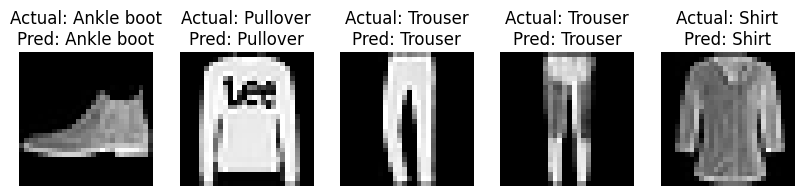

In [31]:
plt.figure(figsize=(10,5))

for i in range(5):
    idx = correct_shallow[i]
    
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_shallow[idx]]}")
    plt.axis('off')
plt.savefig("shallow_correct.png")
plt.show()

### Correct Predictions by Shallow CNN

A sample of correctly classified images from the shallow CNN model shows that:

- The predicted labels match the actual labels for all displayed images.
- The model performs well on clearly distinguishable classes such as:
  - Ankle boot
  - Trouser
  - Pullover
  - Shirt

#### Interpretation

These examples indicate that the shallow CNN is effective at recognizing:
- Distinct shapes (e.g., shoes vs clothing)
- Simple textures and outlines

#### Key Insight

The model performs particularly well on images where the class features are visually clear and less ambiguous.

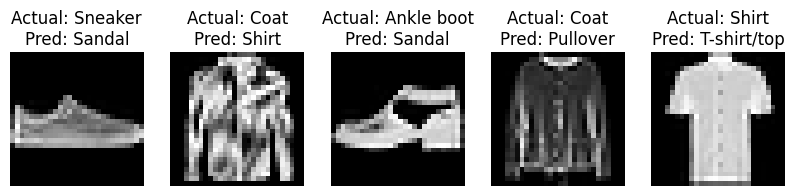

In [32]:
plt.figure(figsize=(10,5))

for i in range(5):
    idx = incorrect_shallow[i]
    
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_shallow[idx]]}")
    plt.axis('off')
plt.savefig("shallow_incorrect.png")
plt.show()

### Incorrect Predictions by Shallow CNN

A sample of incorrectly classified images reveals the limitations of the shallow CNN.

#### Observed Misclassifications

- Sneaker → predicted as Sandal
- Ankle boot → predicted as Sandal
- Coat → predicted as Shirt or Pullover
- Shirt → predicted as T-shirt/top

#### Interpretation

The model struggles with **visually similar classes**, especially:
- Footwear categories (Sneaker, Sandal, Ankle boot)
- Upper-body clothing (Shirt, T-shirt, Coat, Pullover)

These classes share similar shapes and textures, making them harder to distinguish with limited feature extraction.

#### Key Insight

The shallow CNN fails when:
- Differences between classes are subtle
- More detailed or hierarchical feature understanding is required

This highlights the limitation of shallow architectures in capturing fine-grained distinctions.

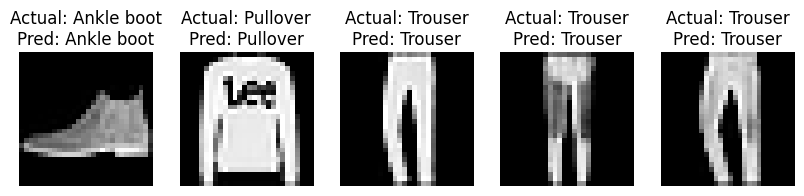

In [33]:
plt.figure(figsize=(10,5))

for i in range(5):
    idx = correct_deep[i]
    
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_deep[idx]]}")
    plt.axis('off')
plt.savefig("deep_correct.png")
plt.show()

### Correct Predictions by Deep CNN

A sample of correctly classified images from the deep CNN model shows:

- The predicted labels match the actual labels for all displayed images.
- The model correctly identifies clear and distinct classes such as:
  - Ankle boot
  - Trouser
  - Pullover

#### Interpretation

The deep CNN successfully learns patterns for:
- Clearly distinguishable objects
- Classes with strong visual identity

#### Key Insight

The deep CNN performs well on straightforward classification cases, similar to the shallow CNN. This indicates that both models are capable of learning basic and moderately complex patterns effectively.

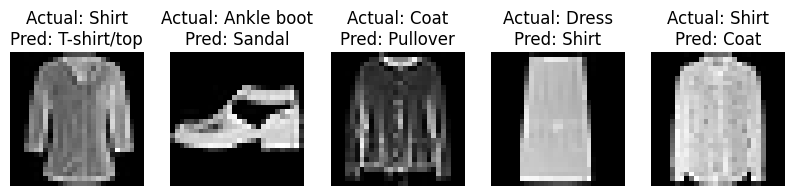

In [34]:
plt.figure(figsize=(10,5))

for i in range(5):
    idx = incorrect_deep[i]
    
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_deep[idx]]}")
    plt.axis('off')
plt.savefig("deep_incorrect.png")
plt.show()

### Incorrect Predictions by Deep CNN

A sample of incorrectly classified images from the deep CNN shows similar patterns of errors as the shallow CNN.

#### Observed Misclassifications

- Shirt → predicted as T-shirt/top or Coat
- Ankle boot → predicted as Sandal
- Coat → predicted as Pullover
- Dress → predicted as Shirt

#### Interpretation

The deep CNN struggles with **visually similar categories**, especially:
- Upper-body clothing (Shirt, T-shirt, Coat, Pullover)
- Footwear (Ankle boot vs Sandal)

These misclassifications are very similar to those observed in the shallow CNN.

#### Key Insight

Even with deeper architecture, the model:
- Still finds it difficult to distinguish between similar-looking classes
- Does not significantly reduce classification errors in confusing categories

This suggests that increasing depth alone is not sufficient to solve fine-grained classification challenges in this dataset.

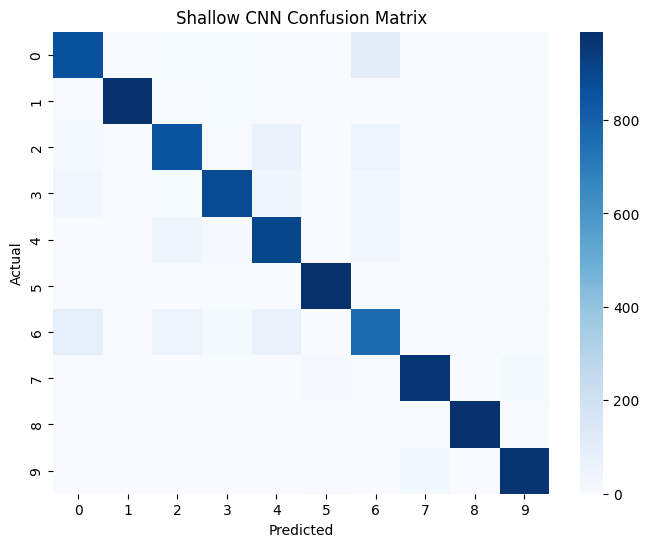

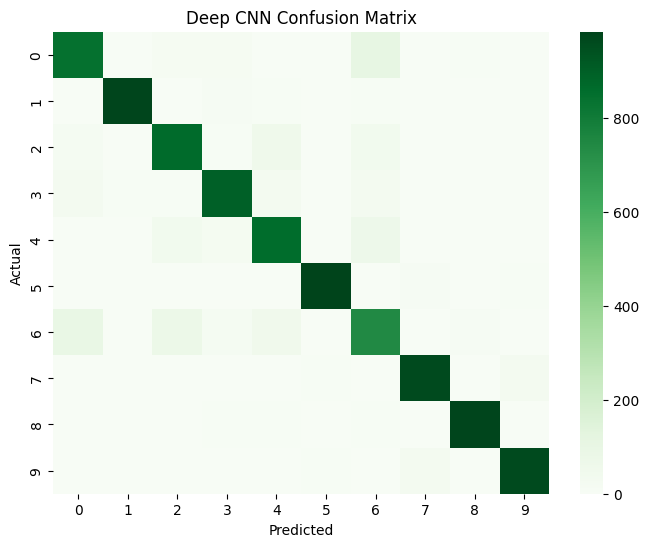

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix - Shallow CNN
cm_shallow = confusion_matrix(y_test, y_pred_shallow)

plt.figure(figsize=(8,6))
sns.heatmap(cm_shallow, annot=False, cmap='Blues')
plt.title("Shallow CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("shallow_confusion_matrix.png")
plt.show()

# Confusion Matrix - Deep CNN
cm_deep = confusion_matrix(y_test, y_pred_deep)

plt.figure(figsize=(8,6))
sns.heatmap(cm_deep, annot=False, cmap='Greens')
plt.title("Deep CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("deep_confusion_matrix.png")
plt.show()

### Confusion Matrix Analysis and Error Insights

The confusion matrices for both shallow and deep CNN models provide a detailed view of classification performance across all classes.

#### Which classes were easiest to classify?

The easiest classes to classify are those with strong diagonal values (high correct predictions), such as:
- Trouser
- Sneaker
- Bag
- Ankle boot

These classes have distinct shapes and features, making them easier for both models to identify correctly.

---

#### Which classes were most commonly confused?

The most commonly confused classes are:
- Shirt, T-shirt/top, Pullover, and Coat
- Sneaker, Sandal, and Ankle boot

These classes share similar visual characteristics such as:
- Similar shapes
- Overlapping textures
- Lack of distinctive features in grayscale images

---

#### Did the deep CNN reduce confusion between similar-looking classes?

No, the deep CNN did **not significantly reduce confusion** between similar-looking classes.

- The confusion patterns in both models are very similar
- Misclassifications between clothing categories (e.g., Shirt vs T-shirt) persist
- Footwear confusion (Sneaker vs Sandal) is still present

#### Key Insight

While the deep CNN has greater capacity to learn complex features, this did not translate into improved discrimination between visually similar classes in this dataset.

This suggests that:
- The dataset complexity may not require deeper architectures
- Additional techniques (data augmentation, regularization, or different architectures) may be needed for further improvement

### Final Comparative Conclusion

Based on the complete experimental analysis of shallow CNN and deep CNN on the Fashion-MNIST dataset, the following conclusions can be drawn:

#### Which model would you recommend for Fashion-MNIST?

The **shallow CNN is recommended** for the Fashion-MNIST dataset. It achieves slightly better accuracy while maintaining a simpler architecture.

---

#### Which model was more efficient?

The **deep CNN was more efficient in terms of training time and parameter usage**:
- It trained faster (~120 seconds vs ~217 seconds)
- It used fewer parameters (241K vs 693K)

However, this efficiency did not translate into better performance.

---

#### Which model was more accurate?

The **shallow CNN was more accurate**:
- Test Accuracy: ~91.85% (Shallow CNN)
- Test Accuracy: ~91.12% (Deep CNN)

Although the difference is small, the shallow model consistently performed better across validation and test sets.

---

#### What did you learn from this comparative study?

This study highlights several important insights:

- Increasing model depth does not always guarantee better performance.
- Simpler models can perform equally well or better on relatively simple datasets.
- Deep CNNs are capable of learning complex representations, but may not provide significant benefits without sufficient data complexity.
- Model design should balance complexity, performance, and efficiency rather than assuming deeper is always better.

#### Final Insight

For datasets like Fashion-MNIST, a well-designed shallow CNN can be both effective and sufficient, making it a practical choice over deeper architectures.

In [24]:
pip install pandoc

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 2.3 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.5 MB 1.6 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.5 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.4 MB/s eta 0:00:05


In [26]:
import pypandoc
pypandoc.download_pandoc()